In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict,Annotated,Literal,List,Any
from pydantic import Field,BaseModel
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import  operator
from langchain_huggingface import HuggingFaceEmbeddings,HuggingFaceEndpoint
import os
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import PyPDFLoader,WebBaseLoader
from langchain_core.runnables import RunnableSequence
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from fastapi import FastAPI,HTTPException
from langchain_community.retrievers import BM25Retriever
try:
    from langchain.retrievers import EnsembleRetriever
except ImportError:
    from langchain_classic.retrievers import EnsembleRetriever
from fastapi.middleware.cors import CORSMiddleware
import psutil
import uvicorn
import hashlib
import logging
import asyncio
import time
import asyncio
import uuid
import nest_asyncio
from fastapi.middleware.cors import CORSMiddleware

C:\Users\ayush\AppData\Local\Temp\ipykernel_2436\981964801.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader,WebBaseLoader


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
app = FastAPI()

In [3]:
class AgentState(TypedDict):
    thread_id : Annotated[str,Field(...,description='Session/thread Identifier')]
    file_path : Annotated[str,Field(...,description="Path to Upload document")]
    question :Annotated[str,Field(...,description="Question of the User")]
    docs : Annotated[List[Any],Field(default_factory=list)]
    chunks : Annotated[List[Any],Field(default_factory=list)]
    retriever : Annotated[List[Any],Field(default=None)]
    retrieval : Annotated[List[Any],Field(default=None)]

In [4]:
llm = ChatGroq(model = "qwen/qwen3.8-27b",api_key= os.getenv("GROQ_API_KEY"),temperature= 0.3)

In [5]:
EMBEDDING_MODEL = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
PERSIST_ROOT = "./chroma_store"
DOC_CACHE: dict = {}         
CHUNK_CACHE: dict = {}       
RETRIEVER_STORE: dict = {}    
ANSWER_CACHE: dict = {}      
def _file_fingerprint(file_path: str) -> str:
    """Hash file path + mtime so re-uploading the same file for a new
        thread_id can still be detected as unchanged if you extend caching by
        file fingerprint instead of thread_id."""
    try:
            mtime = os.path.getmtime(file_path)
    except OSError:
        mtime = 0
        return hashlib.sha256(f"{file_path}:{mtime}".encode()).hexdigest()


In [6]:
def process_pdf(file_path: str) -> list:
    """Actually load the PDF (this was previously a stub that returned None)."""
    if not file_path or not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    loader = PyPDFLoader(file_path)
    return loader.load()


def load_documents(state: AgentState) -> dict:
    thread_id = state.get("thread_id")
    file_path = state.get("file_path")

    if not file_path or not thread_id:
        logging.error("Missing file_path or thread_id in state.")
        return {"docs_status": "ERROR", "docs": []}

    if thread_id in DOC_CACHE:
        logging.info("Using cached parsed documents for thread %s", thread_id)
        return {"docs_status": "READY", "docs": DOC_CACHE[thread_id]}

    try:
        logging.info("Loading PDF: %s", file_path)
        parsed_docs = process_pdf(file_path)
        DOC_CACHE[thread_id] = parsed_docs
        return {"docs_status": "READY", "docs": parsed_docs}
    except Exception as e:
        logging.exception("Document processing failed: %s", e)
        return {"docs_status": "FAILED", "docs": []}

In [7]:
def text_split(state: AgentState) -> dict:
    thread_id = state.get("thread_id")

    if thread_id in CHUNK_CACHE:
        return {"chunks": CHUNK_CACHE[thread_id]}

    documents = state.get("docs", [])
    if not documents:
        return {"chunks": []}

    try:
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
        divided_chunks = text_splitter.split_documents(documents)
        CHUNK_CACHE[thread_id] = divided_chunks
        return {"chunks": divided_chunks}
    except Exception as e:
        print(f"Text split error: {e}")
        return {"chunks": []}

In [8]:
def Embeddings(state: AgentState) -> dict:
    thread_id = state["thread_id"]
    chunks_to_embed = state.get("chunks", [])

    if thread_id in RETRIEVER_STORE:
        return {}

    if not chunks_to_embed:
        return {}

    try:
        vector_store = Chroma.from_documents(
            documents=chunks_to_embed,
            embedding=EMBEDDING_MODEL,
            collection_name=f"session_{thread_id}",
            persist_directory=os.path.join(PERSIST_ROOT, thread_id),
        )
        vector_retriever = vector_store.as_retriever(search_kwargs={"k": 3})

        bm25_retriever = BM25Retriever.from_documents(chunks_to_embed)
        bm25_retriever.k = 3

        hybrid_retriever = EnsembleRetriever(
                    retrievers=[vector_retriever, bm25_retriever],
                    weights=[0.5, 0.5],
                )
        
        RETRIEVER_STORE[thread_id] = hybrid_retriever
        return {}

    except Exception as e:
        print(f"Embedding error: {e}")
        return {}

In [9]:
def retriever(state: AgentState) -> dict:
    """Runs the actual similarity search. Kept as its own node so retrieval
    (fetching) and retrieval-answer-generation (below) stay separate concerns."""
    thread_id = state["thread_id"]
    question = state.get("question", "")

    actual_retriever = RETRIEVER_STORE.get(thread_id)
    if not actual_retriever:
        return {"retrieved_docs": state.get("chunks", [])[:3]}

    try:
        matched_documents = actual_retriever.invoke(question)
        if not matched_documents:
            matched_documents = state.get("chunks", [])[:3]
        return {"retrieved_docs": matched_documents}
    except Exception as e:
        print(f"Retrieval error: {e}")
        return {"retrieved_docs": state.get("chunks", [])[:3]}

In [10]:
async def retrieval(state: AgentState) -> dict:
    """Takes the documents `retriever` found and asks the LLM to synthesize
    an answer from them."""
    question = state.get("question", "")
    thread_id = state.get("thread_id")
    documents = state.get("retrieved_docs", [])

    cache_key = (thread_id, question)
    if cache_key in ANSWER_CACHE:
        return {"retrieval": ANSWER_CACHE[cache_key]}

    if not documents:
        return {"retrieval": "No relevant content found in the document, please check it loaded correctly."}

    MAX_CONTEXT_CHARS = 6000
    content = " ".join(doc.page_content for doc in documents)[:MAX_CONTEXT_CHARS]

    prompt = f"""You are an expert AI research scientist. Provide a comprehensive, highly detailed, and deep analytical answer to the question based on the provided context.

CRITICAL INSTRUCTIONS:
- Output your entire response as a single, continuous, deep analytical text paragraph.
- Do NOT use bullet points, numbered lists, markdown headings, or line breaks.
- Bold key concepts inside the text paragraph.
- Expand thoroughly on every goal mentioned in the context, weaving them together into a dense academic narrative.
- CRITICAL: Do not output any thinking steps, scratchpad text, or <think></think> markdown tags. Output ONLY the raw final text paragraph.

Context:
{content}

Question: {question}
Deep Analytical Answer:"""

    try:
        response = await llm.ainvoke(prompt)
        final_text = str(response.content).strip()
        if "</think>" in final_text:
            final_text = final_text.split("</think>")[-1].strip()

        ANSWER_CACHE[cache_key] = final_text
        return {"retrieval": final_text}
    except Exception as e:
        logging.exception("LLM call failed: %s", e)
        return {"retrieval": ""}

In [11]:
graph = StateGraph(AgentState)

graph.add_node('load_docs',load_documents)
graph.add_node('text_split',text_split)
graph.add_node('embeddings',Embeddings)
graph.add_node('retriever',retriever)
graph.add_node('retrieval',retrieval)

graph.add_edge(START,'load_docs')
graph.add_edge('load_docs','text_split')
graph.add_edge('text_split','embeddings')
graph.add_edge('embeddings','retriever')
graph.add_edge('retriever','retrieval')
graph.add_edge('retrieval',END)

memory = InMemorySaver()
model = graph.compile(checkpointer=memory)

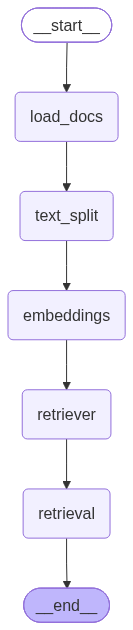

In [12]:
model

In [16]:
async def run_query(file_path: str, question: str, thread_id: str | None = None) -> dict:
    thread_id = thread_id or str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    initial_state = {
        "thread_id": thread_id,
        "file_path": file_path,
        "question": question,
    }
    t0 = time.perf_counter()
    result = await model.ainvoke(initial_state, config=config)
    elapsed = time.perf_counter() - t0
    print(f"[thread {thread_id}] answered in {elapsed:.2f}s")
    return result

thread_id = str(uuid.uuid4())
final_output = await run_query(
    file_path=r"C:\\Users\\ayush\\Downloads\\MultiAgent_AISYSTEM.pdf",
    question="What is Multi AI Agent?",
    thread_id=thread_id,
)
print("final_output", final_output)

[thread 6fcef06a-5005-4bb1-9452-99f889819f5f] answered in 12.70s
final_output {'thread_id': '6fcef06a-5005-4bb1-9452-99f889819f5f', 'file_path': 'C:\\\\Users\\\\ayush\\\\Downloads\\\\MultiAgent_AISYSTEM.pdf', 'question': 'What is Multi AI Agent?', 'docs': [Document(metadata={'producer': 'LuaHBTeX, Version 1.16.0 (TeX Live 2023)', 'creator': 'LaTeX with acmart 2025/08/27 v2.16 Typesetting articles for the Association for Computing Machinery and hyperref 2023-02-07 v7.00v Hypertext links for LaTeX', 'creationdate': '2026-04-01T11:14:01+00:00', 'moddate': '2026-04-01T11:14:01+00:00', 'ptex.fullbanner': 'This is LuaHBTeX, Version 1.16.0 (TeX Live 2023)', 'subject': '-  Information systems—Information systems applications—Multimedia information systems;', 'title': 'LLM-Powered Multi-Agent Systems: A Survey of Collaboration and Learning Strategies', 'trapped': '/False', 'source': 'C:\\\\Users\\\\ayush\\\\Downloads\\\\MultiAgent_AISYSTEM.pdf', 'total_pages': 13, 'page': 0, 'page_label': '1'},